# HARPS-N tools

## Object visibility

##### Imports

In [139]:
# imports
import sys
import numpy as np
from matplotlib import pyplot as plt

from astropy.time import Time
from astropy import units as u
from astropy import constants as const
from astropy.visualization import time_support, quantity_support
quantity_support()
time_support()
from astropy.coordinates import SkyCoord, EarthLocation, get_body

from helper_functions import whatsGoingOnTonight, hourText, find_moondist

import warnings
warnings.filterwarnings('ignore')

### Inputs

In [140]:
### OBSERVING DATE
Observing_Date = 'now' # enter a date (YYYY-MM-DD) or the string 'now'

### TARGETS
# night 1
# starname = ['M6', 'AT53', 'TOI-5626', 'TIC357786383', 'G58-25', 'G56-36', 'G165-39', 'G16-30', 'G180-24'] # enter star name(s) into this list (e.g. 'Vega')
# RA = ["00h27m00.0s", "18h07m44.45s", "13h13m00.0s", "13h13m00.0s", "10h51m00.0s", "11h23m00.0s", "13h59m00.0s", "15h50m00.0s", "16h03m00.0s"] # enter right ascension value(s) here in the form 'XXhXXmXX.XXXs'
# DEC = ["+70d00m00.0s", "+39d04m26.92s", "+31d00m00.0s", "+31d00m00.0s", "+20d00m00.0s", "+19d00m00.0s", "+19d00m00.0s", "+8d00m00.0s", "+42d00m00.0s"] # enter declination value(s) here in the form 'XXdXXmXX.XXXs'

# night 2
starname = ["GFU43", "AMS17", "HD146233", "M6"]
RA = ["16h53m43.79s", "15h05m49.90s", "16h15m37.27s", "00h26m52.7s"]
DEC = ["-00d22m58.56s", "64d02m49.94s", "-08d22m09.982s", "+70d08m32.72s"]

### TRANSIT
transit = False # set to true if transit night and add in times below
tstart = "2026-05-18 22:50:00"
tend = "2026-05-19 04:04:00"

#### Process inputs

In [141]:
### LOCATION
# (technically an input but it'll remain the same)

# keep as ORM...
observatory = 'Roque de los Muchachos' # e.g. 'Roque de los Muchachos' (string)



# ... or enter the observatory's latitude, longitude, and elevation here
def todeg(h, m, s):
    """ Convert from sexagesimal to degrees. Use for the inputs below. """
    return h+m/60+s/3600

latitude = None # in degrees (float)
longitude = None # in degrees (float)
elevation = None # in metres (float)

In [142]:
### LOCATION

if type(latitude) == float: # choose if the user has input a location name or coordinates
    location = EarthLocation(lat=latitude*u.deg, lon=longitude*u.deg, height=elevation*u.m)
if latitude == None and observatory == None:
    raise ValueError("Please input a location in input.py. You can input a latitude, longitude, and elevation, or the name of an observatory (see astropy.coordinates.EarthLocation.of_site)")
if type(observatory) == str:
    location = EarthLocation.of_site(observatory)
    

### OBSERVING DATE
    
now = Time(Time.now(), location=location, format='iso', scale='utc')
today = Time(now.iso.split()[0], location=location) # <--- if you want to see tonight

if Observing_Date == 'now':
    if float(now.datetime.hour) > 12.: # because of how the day is defined. Sunset is the date - 1 day, easier just to add a day now so I did
        observing_date = today  + 1*u.day # vis today
    else:
        observing_date = today
    plotnow = True
else:
    obsdate = Time(Observing_Date, location=location, format='iso', scale='utc')
    observing_date = obsdate + 1*u.day # vis on given date
    plotnow = False

    
### TARGET(S)

targets = []
for i in range(len(RA)):
    targets.append(SkyCoord(ra=RA[i], dec=DEC[i], frame="icrs"))

In [143]:
### TELESCOPE (TNG)
lower_shutter = None
lower_limit = 14 # degrees height
dead_zone = 89 # cannot track within 1 deg of zenith
telescope = 'TNG (3.58 m)'

In [144]:
### SUN AND MOON
sun = get_body('sun', observing_date)
moon = get_body('moon', observing_date)

In [145]:
### TRANSIT
transit = False # set to true if transit night and add in times below
if transit:
    transit_start = Time(tstart, location=location)
    transit_end = Time(tend, location=location)
else:
    transit_start = None
    transit_end = None  

In [146]:
### UNITS
deg = u.degree
m = u.meter

In [147]:
def run_staralt(showtarget=None):
    # calculate all stuff for moon
    night_moon, altitudes_moon, azimuths_moon, sunriseset_moon, twlt_moon, trans_moon, midnight_moon = whatsGoingOnTonight(location, observing_date, moon)

    # calculate all stuff for target(s)
    target_list = []
    separations = [] # separation from moon

    for i in range(len(targets)):
        target = targets[i]
        night, altitudes, azimuths, sunriseset, twlt, trans, midnight = whatsGoingOnTonight(location, observing_date, target)
        target_list.append([night, altitudes])
        
        if trans[0] > 85:
            print(f"Warning: {starname[i]} transits at an altitude of {trans[0]:.1f} degrees. The ALTAZ mount cannot track through 90 degrees.")

        # separation from moon
        seps_target = []
        
        for i in range(len(altitudes)):
            mn = [altitudes_moon[i], azimuths_moon[i]]
            targ = [altitudes[i], azimuths[i]]
            seps_target.append(find_moondist(mn, targ))
            
        separations.append(seps_target)
        
        
    # night, altitudes, azimuths, sunriseset, twlt, trans, midnight = whatsGoingOnTonight(location, observing_date, targets[0])
    night = target_list[0][0] # array of times for the night

    # create the plot
    fig, ax = plt.subplots(figsize=[20, 10])

    textHeight = 65 # the bottom of the annotation text (in degrees of altitude)

    # SUNRISE AND SUNSET
    backColour = '#000510'

    # sunrise
    ax.vlines(sunriseset[0], 0, 90, 
            color='red', 
            linestyle='dashed', 
            alpha=0.75
            ) # line showing sunset

    ax.annotate(f'Sunset: {hourText(sunriseset[0])}', 
                (sunriseset[0] + 0.0075*u.d, textHeight), 
                color='red', 
                rotation=90, 
                fontsize=8, 
                fontweight='bold'
            )


    # sunset
    ax.vlines(sunriseset[1], 0, 90, 
            color='red', 
            linestyle='dashed', 
            alpha=0.75
            ) # line showing sunrise

    ax.annotate(f'Sunrise: {hourText(sunriseset[1])}', 
                (sunriseset[1] - 0.012*u.d, textHeight), 
                color='red', 
                rotation=90, 
                fontsize=8, 
                fontweight='bold'
            )

    # fill
    ax.fill_between(np.linspace(sunriseset[0], sunriseset[1]), 0, 90, 
                    color=backColour, 
                    alpha=0.4
                ) # darken



    # TWILIGHT
    # civil
    ax.fill_between(np.linspace(twlt[0][0], twlt[0][1]), 0, 90, 
                    color=backColour, 
                    alpha=0.5
                )

    ax.annotate(f'Civil: {hourText(twlt[0][0])}', 
                (twlt[0][0] - 0.012*u.d, textHeight), 
                color='k', 
                rotation=90, 
                fontsize=8, 
                fontweight='bold'
            )


    ax.annotate(f'Civil: {hourText(twlt[0][1])}', 
                (twlt[0][1] + 0.0075*u.d, textHeight), 
                color='k', 
                rotation=90, 
                fontsize=8, 
                fontweight='bold'
            )


    # nauticle
    ax.fill_between(np.linspace(twlt[1][0], twlt[1][1]), 0, 90, 
                    color=backColour, 
                    alpha=0.5
                )

    ax.annotate(f'Nauticle: {hourText(twlt[1][0])}', 
                (twlt[1][0] - 0.012*u.d, textHeight), 
                color='#909090', 
                rotation=90, 
                fontsize=8, 
                fontweight='bold'
            )

    ax.annotate(f'Nauticle: {hourText(twlt[1][1])}', 
                (twlt[1][1] + 0.0075*u.d, textHeight), 
                color='#909090', 
                rotation=90, 
                fontsize=8, 
                fontweight='bold'
            )


    # astronomical
    try:
        ax.fill_between(np.linspace(twlt[2][0], twlt[2][1]), 0, 90, 
                        color=backColour, 
                        alpha=0.5
                    )
        
        ax.annotate(f'Astronomical: {hourText(twlt[2][0])}', 
                    (twlt[2][0] - 0.012*u.d, textHeight), 
                    color='white', 
                    alpha=0.7, 
                    rotation=90, 
                    fontsize=8, 
                    fontweight='bold'
                )
        
        ax.annotate(f'Astronomical: {hourText(twlt[2][1])}', 
                    (twlt[2][1] + 0.0075*u.d, textHeight), 
                    color='white', 
                    alpha=0.7, 
                    rotation=90, 
                    fontsize=8, 
                    fontweight='bold'
                )
    except:
        pass
    
    # PLOT MOON
    ax.plot(night_moon, altitudes_moon, color='grey', linestyle='dashed', alpha=0.75, label='Moon')

    # vertical 'now' line
    if plotnow:
        ax.vlines(now, 0, 90,
                color='#00cc00',
                linestyle='dashed',
                alpha=1.
                ) # plot vertical 'now' line

        ax.annotate(f'{hourText(now)}', 
                (now - 0.012*u.d, textHeight), 
                color='#00cc00', 
                rotation=90, 
                fontsize=8, 
                fontweight='bold'
            ) # annotate now line

    # Transits
    if transit:
        ax.vlines(transit_start, 0, 90,
                color='purple',
                linestyle='solid'
        )
        ax.vlines(transit_end, 0, 90,
                color='purple',
                linestyle='solid'
        )
        ax.fill_between(np.linspace(transit_start, transit_end), 0, 90, 
                            color='purple', 
                            alpha=0.3
                        )

    # LIMITS, LABELS & TITLE
    ax.set_title(fr'{night[0].to_string().split()[0]} $|$ lat={location.lat:.2f} long={location.lon:.2f} elev={location.height:.0f} $|$ telescope = {telescope}', fontsize=14)

    labels = []
    tickvals = []
    for i in range(len(night)-1):
        if night[i].datetime.hour < night[i+1].datetime.hour or night[i].datetime.hour > night[i+1].datetime.hour:
            labels.append(night[i].datetime.hour)
            tickvals.append(night[i]-1*u.hour)

    ax.set_xticks(ticks=Time(tickvals))
    ax.set_xticklabels(labels)

    ax.set_xlabel('Time (UTC)', fontsize=14)
    ax.set_ylim(0, 90), ax.set_ylabel('Altitude (degrees)', fontsize=14)

    if Observing_Date == 'now':
        if now < sunriseset[0]:
            xlim = [now-0.75*u.hour, sunriseset[-1]+1.75*u.hour]
            ax.set_xlim(xlim[0], xlim[1])
        elif now > sunriseset[-1]:
            xlim = [sunriseset[0]-0.75*u.hour, now+1.75*u.hour]
            ax.set_xlim(xlim[0], xlim[1])
        else:
            xlim = [sunriseset[0]-0.75*u.hour, sunriseset[-1]+1.75*u.hour]
            ax.set_xlim(xlim[0], xlim[1])
    else:
        xlim = [sunriseset[0]-0.75*u.hour, sunriseset[-1]+1.75*u.hour]
        ax.set_xlim(xlim[0], xlim[1])

    # TELESCOPE LIMITS
    fillwidth = np.linspace(sunriseset[0], sunriseset[-1])
    # fillwidth = np.linspace(xlim[0], xlim[1])

    try:
        # lower shutter limit
        ax.fill_between(fillwidth, 0, lower_shutter, 
                        color='#000000', 
                        alpha=0.3
                    )

        ax.annotate(f'Lower shutter limit', 
                    (twlt[2][1] + 0.1*u.hour, lower_shutter - 1.5), 
                    color='orange', 
                    rotation=0, 
                    fontsize=8, 
                    fontweight='bold'
                ) # annotate lower shutter line
    except:
        pass

    try:
        # lower telescope limit
        ax.fill_between(fillwidth, 0, lower_limit, 
                        color='#000000', 
                        alpha=0.3
                    )

        ax.annotate(f'Lower telescope limit', 
                    (twlt[2][1] + 0.1*u.hour, lower_limit - 1.5), 
                    color='orange', 
                    rotation=0, 
                    fontsize=8, 
                    fontweight='bold'
                ) # annotate lower limit line
    except:
        pass

    try:
        # dead zone (e.g. tng altaz limits)
        ax.fill_between(fillwidth, dead_zone, 90,
                        color='#000000', 
                        alpha=0.6
                    )

        ax.annotate(f'Dead zone', 
                    (twlt[2][1] + 0.1*u.hour, dead_zone - 0.5), 
                    color='orange', 
                    rotation=0, 
                    fontsize=8, 
                    fontweight='bold'
                ) # annotate lower limit line
    except:
        pass

    # airmass limit (from TNG CAT instructions)
    airmass_limit = 90 - np.arccos(1/1.8)*180/np.pi
    ax.fill_between(fillwidth, 0, airmass_limit,
                    color='#000000', 
                    alpha=0.3
                )

    ax.annotate(f'Airmass limit (AM=1.8)', 
                (twlt[2][1] + 0.1*u.hour, airmass_limit - 1.5), 
                color='orange', 
                rotation=0, 
                fontsize=8, 
                fontweight='bold'
            ) # annotate lower limit line
    
    # ALTITUDE & MOON SEPARATION

    colours = ['#005F73', '#0A9396', '#94D2BD', '#E9D8A6', '#EE9B00', '#CA6702', '#BB3E03', '#AE2012'] # ignore this if you want lol
    # colours = ['#D8F3DC', '#B7E4C7', '#95D5B2', '#74C69D', '#52B788', '#40916C', '#2D6A4F', '#1B4332'] # green palette

    for i in range(len(target_list)):
        if type(showtarget) == str:
            if starname[i] == showtarget: # if a target has been specified, plot it with more oomph
                times_target = target_list[i][0]
                alts_target = target_list[i][1]
                ax.plot(times_target, alts_target, alpha=1.0, color=colours[-i], label=starname[i])
                print(i)
                diffs = []
                for l in range(len(times_target)):
                    diffs.append(abs(times_target[l] - now))

                t0 = times_target[np.argmin(diffs)]
                alt0 = alts_target[np.argmin(diffs)]

                # plot emoji
                if twlt[2][1] < t0 < twlt[2][0] and alt0 > airmass_limit and alt0 < dead_zone:
                    m = ":)"
                    c = "yellow"
                elif twlt[2][1] < t0 < twlt[2][0] and airmass_limit > alt0 > lower_limit and alt0 < dead_zone:
                    m = ":/"
                    c = "orange"
                else:
                    m = ":("
                    c = "red"
                    
                # create 'emoji'
                plt.scatter(t0, alt0, marker='o', color=c, s=400, zorder=5)
                try:
                    ax.text(t0, alt0, m, fontsize=15, ha='center', va='center', zorder=6, rotation=270)
                except Exception:
                    pass

                for k in range(15): # annotate the moon separations
                    index = int(k/15 * len(times_target)) # split times into 15 equal points

                    # print(separations[i])
                    # print(times_target[index])
                    # print(alts_target[index])
                    ax.annotate(f"{separations[i][index]:.0f}", (times_target[index], alts_target[index]), fontsize=10, color=colours[-i])
            else:
                times_other = target_list[i][0]
                alts_other = target_list[i][1]
                ax.plot(times_other, alts_other, alpha=0.25, color=colours[-i], label=starname[i])

                for k in range(15): # annotate the moon separations
                    index = int(k/15 * len(times_other)) # split times into 15 equal points
                    ax.annotate(f"{separations[i][index]:.0f}", (times_other[index], alts_other[index]), fontsize=10, color=colours[-i])
        else:
            times = target_list[i][0]
            alts = target_list[i][1]
            ax.plot(times, alts, alpha=0.75, color=colours[-i], label=starname[i])
            
            for k in range(15): # annotate the moon separations
                index = int(k/15 * len(times)) # split times into 15 equal points
                ax.annotate(f"{separations[i][index]:.0f}", (times[index], alts[index]), fontsize=10, color=colours[-i])

    plt.legend(loc='upper right')

    ### SAVE AND SHOW #############################################

    if len(starname) < 4:
        object_names = '_'.join(starname).replace(' ', '_')
    else:
        object_names = 'multiple_objects'

    fig.savefig(f'ims/object_visibility_{night[0].to_string().split()[0]}_{object_names}.pdf', bbox_inches='tight')
    fig.savefig(f'ims/object_visibility_{night[0].to_string().split()[0]}_{object_names}.png', bbox_inches='tight')

    plt.show()

    print("Sunset", hourText(sunriseset[0]))
    print("Sunrise", hourText(sunriseset[1]))

### Run staralt

1


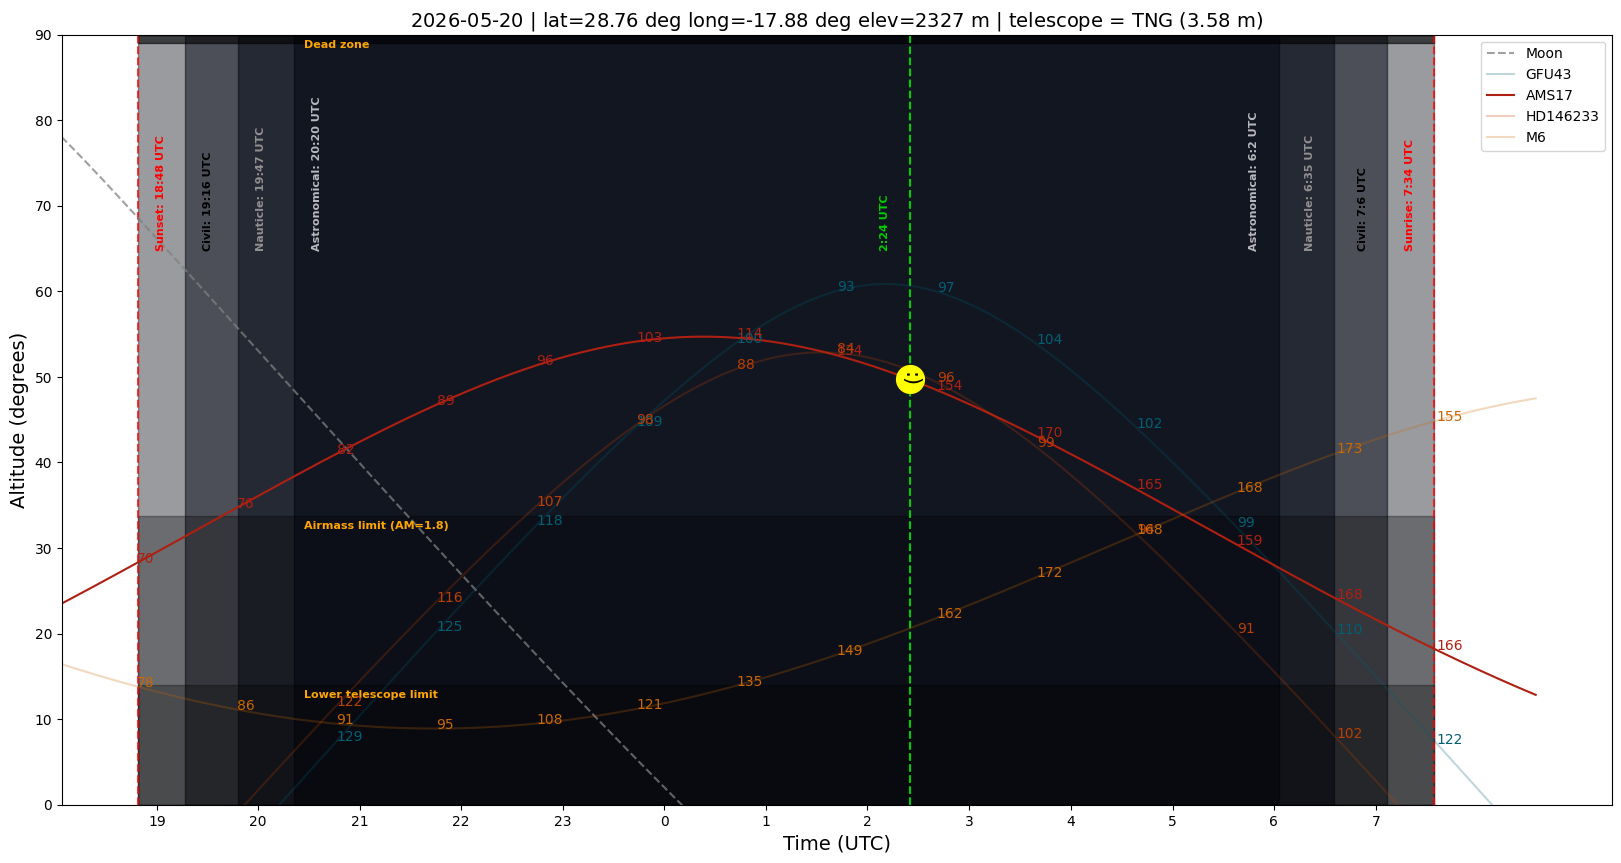

Sunset 18:48 UTC
Sunrise 7:34 UTC


In [148]:
run_staralt(showtarget=starname[1])